# Take Home Project DATA ANALYST  
## Retail Inventory Performance & Profitability Analysis

**Name:** Anthony Djiady Djie  
**Class:** Dibimbing DS39+  

---

## Project Background

This dataset contains retail inventory item-level records, including:

- product information
- cost and retail price
- inventory creation date
- sold date
- category, brand, department, and distribution center information

The analysis aims to uncover actionable business insights related to:

1. profitability  
2. inventory turnover  
3. product/category/brand performance  
4. distribution center performance  
5. time-based sales trends

## Problem Statement

Retail companies often struggle to optimize inventory performance and profitability.

Main business questions:

1. Which products, categories, and brands are the most profitable?
2. Which categories sell the fastest?
3. Which products are slow-moving and may create inventory inefficiency?
4. Are there performance differences across distribution centers?
5. How do sales trends change over time?

## Project Objective

Provide actionable insights to help the business:

- reduce slow-moving inventory
- improve profitability
- optimize product mix
- support stock planning and distribution decisions

## SECTION 1 — Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Turn into Parquet file and save for streamlit
pd.read_csv('inventory_items.csv').to_parquet('inventory_items.parquet')

In [ ]:
# Load dataset
df = pd.read_csv('inventory_items.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id
0,67971,13844,2022-07-02 07:09:20+00:00,2022-07-24 06:33:20+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
1,67972,13844,2023-12-20 03:28:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
2,67973,13844,2023-06-04 02:53:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
3,72863,13844,2021-10-16 22:58:52+00:00,2021-11-22 02:19:52+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
4,72864,13844,2021-08-07 16:33:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7


## SECTION 2 — Data Understanding

In [ ]:
# Dataset shape
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 490,705 rows × 12 columns


In [ ]:
# Column names
df.columns.tolist()

['id',
 'product_id',
 'created_at',
 'sold_at',
 'cost',
 'product_category',
 'product_name',
 'product_brand',
 'product_retail_price',
 'product_department',
 'product_sku',
 'product_distribution_center_id']

In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490705 entries, 0 to 490704
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              490705 non-null  int64  
 1   product_id                      490705 non-null  int64  
 2   created_at                      490705 non-null  object 
 3   sold_at                         181759 non-null  object 
 4   cost                            490705 non-null  float64
 5   product_category                490705 non-null  object 
 6   product_name                    490676 non-null  object 
 7   product_brand                   490304 non-null  object 
 8   product_retail_price            490705 non-null  float64
 9   product_department              490705 non-null  object 
 10  product_sku                     490705 non-null  object 
 11  product_distribution_center_id  490705 non-null  int64  
dtypes: float64(2), i

In [ ]:
# Descriptive statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,490705.0,NaN,NaN,NaN,245353.0,141654.476259,1.0,122677.0,245353.0,368029.0,490705.0
product_id,490705.0,NaN,NaN,NaN,15254.164465,8410.586173,1.0,7984.0,15970.0,22502.0,29120.0
created_at,490705,463339,2020-09-30 15:54:00+00:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sold_at,181759,181526,2022-06-23 02:11:26+00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost,490705.0,NaN,NaN,NaN,28.658986,31.009435,0.0083,11.368,19.832,34.550301,557.151002
product_category,490705,26,Intimates,36353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,490676,27236,Wrangler Men's Premium Performance Cowboy Cut ...,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_brand,490304,2752,Allegra K,17019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_retail_price,490705.0,NaN,NaN,NaN,59.56944,66.592452,0.02,24.5,39.990002,69.949997,999.0
product_department,490705,2,Women,245625,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_summary

,missing_count,missing_pct
sold_at,308946,62.959619
product_brand,401,0.081719
product_name,29,0.005910
id,0,0.000000
created_at,0,0.000000
product_id,0,0.000000
product_category,0,0.000000
cost,0,0.000000
product_retail_price,0,0.000000
product_department,0,0.000000


### Initial Observation

1. `created_at` and `sold_at` should be converted into datetime format.
2. Missing values in `sold_at` likely indicate unsold inventory.
3. `cost` and `product_retail_price` should be checked for invalid values.
4. Categorical columns should be reviewed for uniqueness and consistency.

## SECTION 3 — Data Cleaning

In [ ]:
# Convert datetime columns
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490705 entries, 0 to 490704
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype              
---  ------                          --------------   -----              
 0   id                              490705 non-null  int64              
 1   product_id                      490705 non-null  int64              
 2   created_at                      486300 non-null  datetime64[ns, UTC]
 3   sold_at                         177354 non-null  datetime64[ns, UTC]
 4   cost                            490705 non-null  float64            
 5   product_category                490705 non-null  object             
 6   product_name                    490676 non-null  object             
 7   product_brand                   490304 non-null  object             
 8   product_retail_price            490705 non-null  float64            
 9   product_department              490705 non-null  object             
 

In [ ]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicated rows: {duplicate_count}")

Total duplicated rows: 0


In [ ]:
# Recheck missing values
df.isnull().sum().sort_values(ascending=False)

,0
sold_at,313351
created_at,4405
product_brand,401
product_name,29
id,0
product_id,0
product_category,0
cost,0
product_retail_price,0
product_department,0


In [ ]:
# Validate numerical columns
num_cols = ['cost', 'product_retail_price']

for col in num_cols:
    print(f"{col}")
    print(f"  Min   : {df[col].min()}")
    print(f"  Max   : {df[col].max()}")
    print(f"  Zero  : {(df[col] == 0).sum()}")
    print(f"  Neg   : {(df[col] < 0).sum()}")
    print('-' * 40)

cost
  Min   : 0.0082999997779726
  Max   : 557.1510021798313
  Zero  : 0
  Neg   : 0
----------------------------------------
product_retail_price
  Min   : 0.0199999995529651
  Max   : 999.0
  Zero  : 0
  Neg   : 0
----------------------------------------


In [ ]:
# Drop rows without creation date (cannot track inventory lifecycle)
df = df.dropna(subset=['created_at'])

In [ ]:
# Drop rows without brand name or product name
df = df.dropna(subset=['product_brand', 'product_name'])

In [ ]:
# Remove invalid records
df = df[(df['cost'] >= 0) & (df['product_retail_price'] > 0)]

print(f"Dataset shape after numeric validation: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape after numeric validation: 485,875 rows × 12 columns


In [ ]:
# Check categorical columns
categorical_cols = [
    'product_category',
    'product_name',
    'product_brand',
    'product_department',
    'product_sku'
]

for col in categorical_cols:
    print(f"{col}: {df[col].nunique():,} unique values")
    print('-' * 50)

product_category: 26 unique values
--------------------------------------------------
product_name: 27,215 unique values
--------------------------------------------------
product_brand: 2,752 unique values
--------------------------------------------------
product_department: 2 unique values
--------------------------------------------------
product_sku: 29,020 unique values
--------------------------------------------------


In [ ]:
# Recheck missing values
df.isnull().sum().sort_values(ascending=False)

,0
sold_at,308675
id,0
product_id,0
created_at,0
cost,0
product_category,0
product_name,0
product_brand,0
product_retail_price,0
product_department,0


### Observation
Missing values in sold_at, sold_year, and inventory_days represent products that have not yet been sold.
These values were intentionally kept as NaN because replacing them with zero would incorrectly imply that the product was sold instantly.

## SECTION 4 — Feature Engineering

In [ ]:
# Sold status
df['is_sold'] = np.where(df['sold_at'].notna(), 1, 0)
df['sales_status'] = np.where(df['sold_at'].notna(), 'Sold', 'Unsold')

In [ ]:
# Profit per item
df['profit'] = df['product_retail_price'] - df['cost']

In [ ]:
# Profit margin
df['profit_margin'] = np.where(
    df['product_retail_price'] > 0,
    df['profit'] / df['product_retail_price'],
    np.nan
)

In [ ]:
# Inventory days (for sold items only)
df['inventory_days'] = (df['sold_at'] - df['created_at']).dt.days

In [ ]:
# Extract date features
df['created_year'] = df['created_at'].dt.year
df['created_month'] = df['created_at'].dt.to_period('M').astype(str)

df['sold_year'] = df['sold_at'].dt.year
df['sold_month'] = df['sold_at'].dt.to_period('M').astype(str)

In [ ]:
# Verify engineered columns
df[['sales_status', 'profit', 'profit_margin', 'inventory_days']].head()

,sales_status,profit,profit_margin,inventory_days
0,Sold,4.22196,0.604,21.0
1,Unsold,4.22196,0.604,NaN
2,Unsold,4.22196,0.604,NaN
3,Sold,4.22196,0.604,36.0
4,Unsold,4.22196,0.604,NaN


In [ ]:
# Save DF for Tableau
df.to_csv('inventory_items_tableau.csv', index=False)

## SECTION 5 — Exploratory Data Analysis

In [ ]:
# Create sold-only dataset
sold_df = df[df['is_sold'] == 1].copy()

### 5.1 Overall Business KPIs

In [ ]:
total_items = len(df)
sold_items = df['is_sold'].sum()
unsold_items = total_items - sold_items
sold_rate = sold_items / total_items * 100

total_potential_revenue = df['product_retail_price'].sum()
total_potential_profit = df['profit'].sum()

realized_revenue = sold_df['product_retail_price'].sum()
realized_profit = sold_df['profit'].sum()
avg_inventory_days = sold_df['inventory_days'].mean()

print(f"Total Items                : {total_items:,}")
print(f"Sold Items                 : {sold_items:,}")
print(f"Unsold Items               : {unsold_items:,}")
print(f"Sold Rate                  : {sold_rate:.2f}%")
print(f"Potential Revenue          : {total_potential_revenue:,.2f}")
print(f"Potential Profit           : {total_potential_profit:,.2f}")
print(f"Realized Revenue (Sold)    : {realized_revenue:,.2f}")
print(f"Realized Profit (Sold)     : {realized_profit:,.2f}")
print(f"Average Inventory Days     : {avg_inventory_days:.2f}")

Total Items                : 485,875
Sold Items                 : 177,200
Unsold Items               : 308,675
Sold Rate                  : 36.47%
Potential Revenue          : 28,948,173.07
Potential Profit           : 15,020,657.59
Realized Revenue (Sold)    : 10,553,812.82
Realized Profit (Sold)     : 5,476,314.61
Average Inventory Days     : 29.43


### 5.2 Univariate Analysis

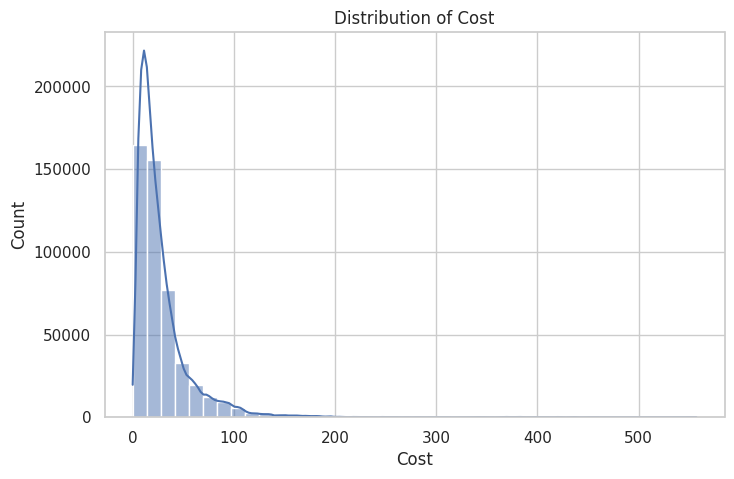

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['cost'], bins=40, kde=True)
plt.title('Distribution of Cost')
plt.xlabel('Cost')
plt.show()

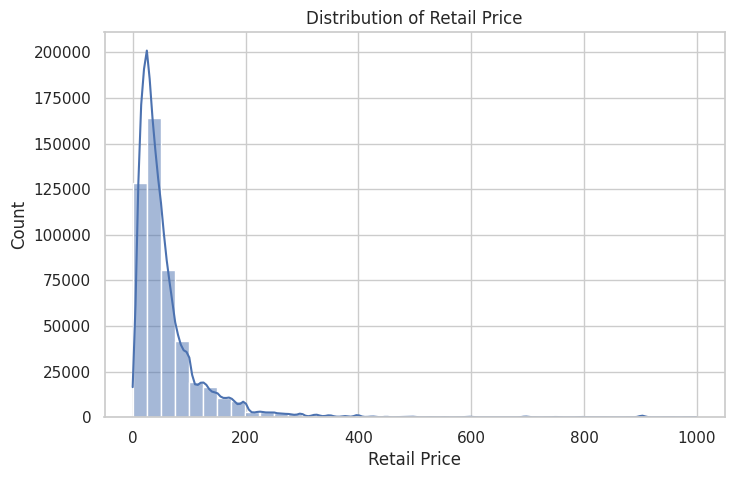

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['product_retail_price'], bins=40, kde=True)
plt.title('Distribution of Retail Price')
plt.xlabel('Retail Price')
plt.show()

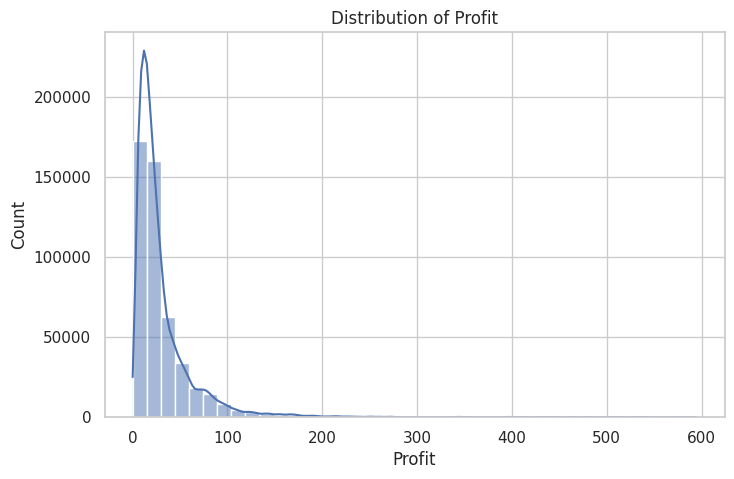

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['profit'], bins=40, kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.show()

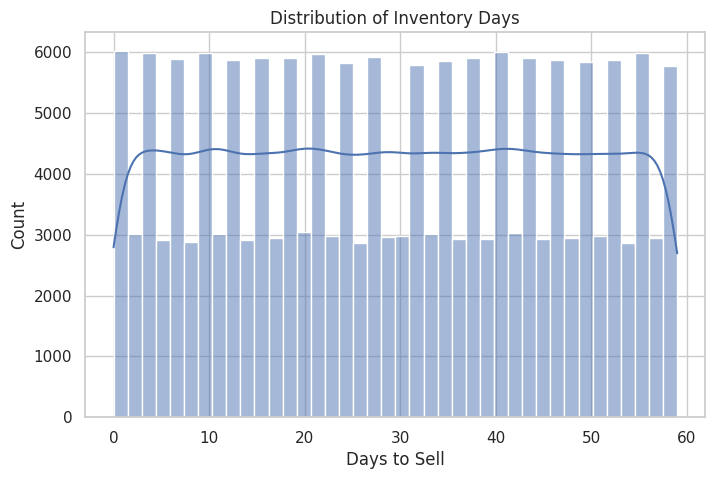

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(sold_df['inventory_days'].dropna(), bins=40, kde=True)
plt.title('Distribution of Inventory Days')
plt.xlabel('Days to Sell')
plt.show()

#### Observation
Retail Business Characteristics

- The store sells mostly low-cost products
- Most items are priced in the affordable range
- Profit per item is generally small but consistent
- Products usually sell within two months


### 5.3 Sales Status Analysis

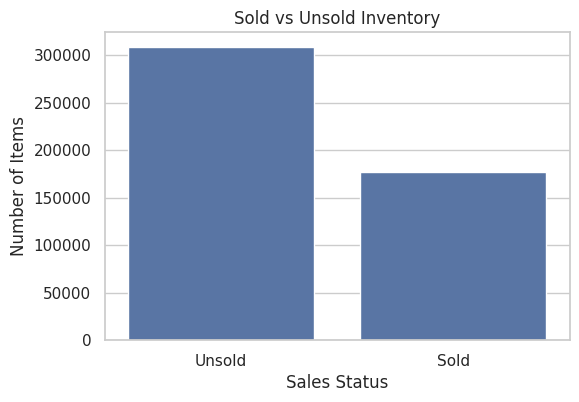

,count
sales_status,
Unsold,308675
Sold,177200


In [ ]:
status_counts = df['sales_status'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title('Sold vs Unsold Inventory')
plt.xlabel('Sales Status')
plt.ylabel('Number of Items')
plt.show()

status_counts

#### Observation
If unsold inventory is large, it indicates capital is tied up in stock and may lead to storage inefficiency.

### 5.4 Category Performance

In [ ]:
category_perf = sold_df.groupby('product_category').agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_inventory_days=('inventory_days', 'mean')
).sort_values(by='revenue', ascending=False)

category_perf.head(10)

,items_sold,revenue,profit,avg_profit_margin,avg_inventory_days
product_category,,,,,
Outerwear & Coats,8709,1.265560e+06,701908.452628,0.555322,29.346423
Jeans,12393,1.223782e+06,568977.014195,0.464750,29.490196
Sweaters,10981,8.224777e+05,426804.192796,0.519393,29.508970
Suits & Sport Coats,5070,6.442716e+05,385514.664680,0.599331,29.492308
Fashion Hoodies & Sweatshirts,11594,6.338173e+05,304794.161189,0.484759,29.253148
Swim,11135,6.296648e+05,308248.596456,0.478221,29.476246
Sleep & Lounge,10716,5.232749e+05,269624.532336,0.513794,29.096305
Shorts,10786,5.005630e+05,249964.268780,0.499706,29.587892
Tops & Tees,11605,4.790556e+05,210857.607746,0.440156,29.402757


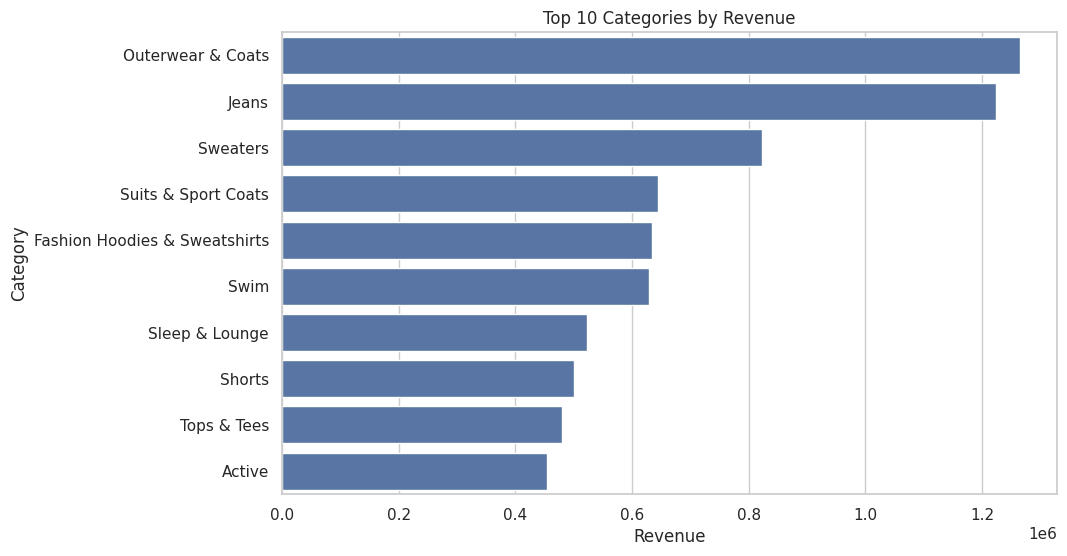

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_perf.head(10).reset_index(),
            x='revenue', y='product_category')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

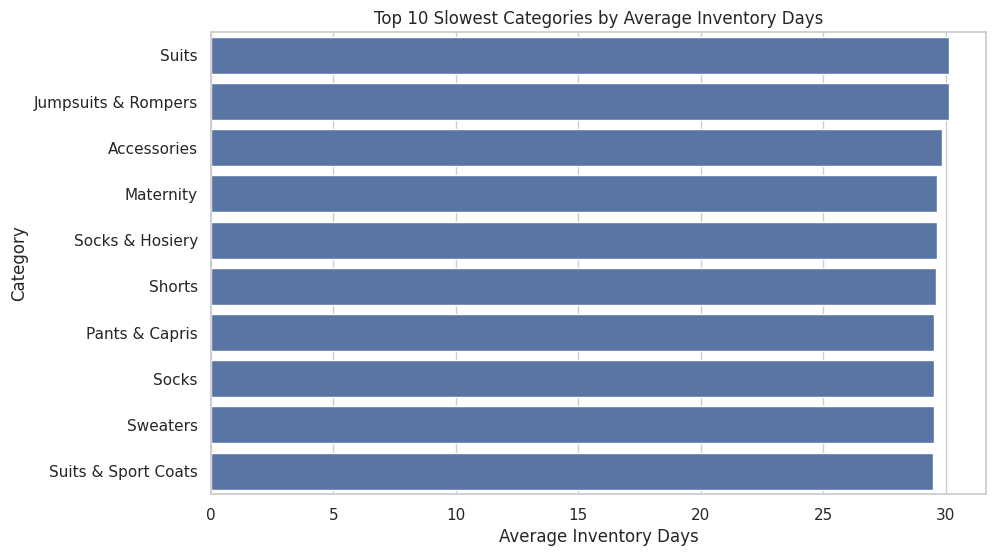

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_perf.sort_values(by='avg_inventory_days', ascending=False).head(10).reset_index(),
            x='avg_inventory_days', y='product_category')
plt.title('Top 10 Slowest Categories by Average Inventory Days')
plt.xlabel('Average Inventory Days')
plt.ylabel('Category')
plt.show()

### 5.5 Brand Performance

In [ ]:
brand_perf = sold_df.groupby('product_brand').agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum'),
    avg_inventory_days=('inventory_days', 'mean')
).sort_values(by='revenue', ascending=False)

brand_perf.head(10)

,items_sold,revenue,profit,avg_inventory_days
product_brand,,,,
Calvin Klein,3195,202857.720502,107686.184835,29.072926
Diesel,1480,192677.569839,95494.323910,29.358108
7 For All Mankind,1159,183879.380543,88077.663529,29.498706
Carhartt,2535,178842.239024,95044.109390,29.471400
True Religion,861,176801.599581,84190.621791,30.249710
Tommy Hilfiger,1624,122654.740139,67284.372289,28.769704
Volcom,1823,104313.609765,50784.036651,29.114098
Quiksilver,1738,102721.190115,47269.273434,29.822209
Columbia,1487,100823.299704,54734.443183,29.531944


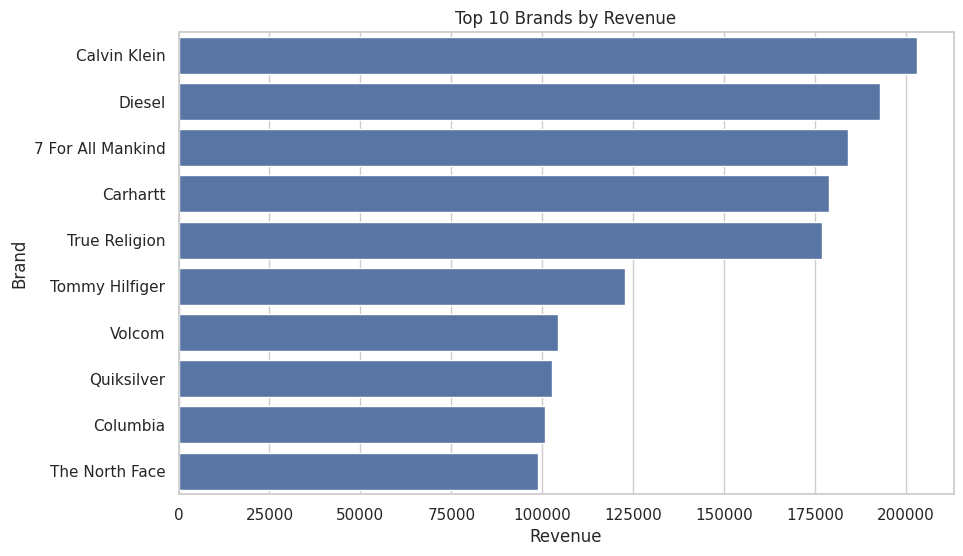

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=brand_perf.head(10).reset_index(),
            x='revenue', y='product_brand')
plt.title('Top 10 Brands by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Brand')
plt.show()

### 5.6 Department Performance

In [ ]:
department_perf = sold_df.groupby('product_department').agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum'),
    avg_inventory_days=('inventory_days', 'mean')
).sort_values(by='revenue', ascending=False)

department_perf

,items_sold,revenue,profit,avg_inventory_days
product_department,,,,
Men,88436,5.583146e+06,2.889652e+06,29.437345
Women,88764,4.970667e+06,2.586662e+06,29.432112


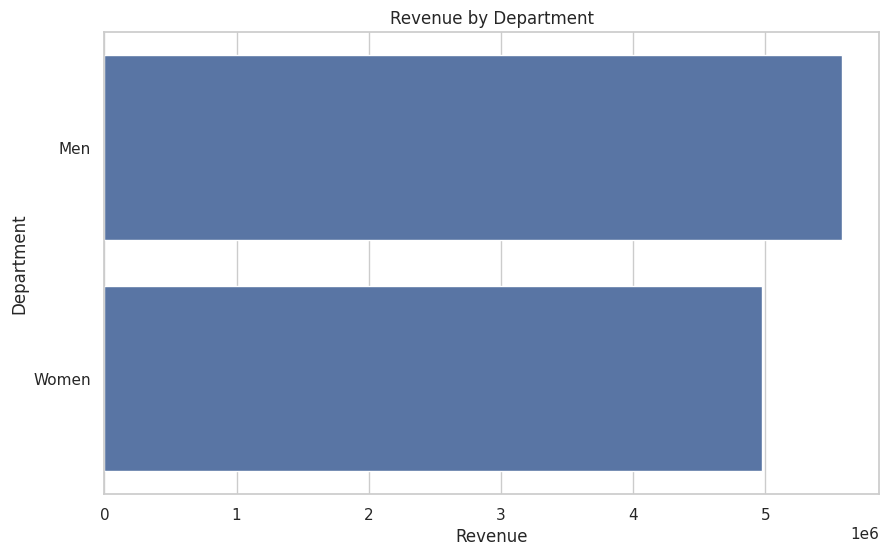

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=department_perf.reset_index(),
            x='revenue', y='product_department')
plt.title('Revenue by Department')
plt.xlabel('Revenue')
plt.ylabel('Department')
plt.show()

### 5.7 Distribution Center Analysis

In [ ]:
dc_perf = sold_df.groupby('product_distribution_center_id').agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum'),
    avg_inventory_days=('inventory_days', 'mean')
).sort_values(by='revenue', ascending=False)

dc_perf

,items_sold,revenue,profit,avg_inventory_days
product_distribution_center_id,,,,
3,22044,1.537749e+06,818249.788574,29.465977
1,23511,1.379704e+06,723062.166566,29.411424
2,23371,1.299197e+06,680853.673507,29.210945
8,18104,1.232766e+06,629962.227971,29.562307
7,16367,1.048013e+06,532532.618815,29.441498
4,16876,9.220595e+05,474911.554698,29.596705
6,15879,9.099537e+05,471555.967459,29.213552
5,12912,7.987787e+05,422279.999947,29.440211
10,11629,7.745110e+05,392608.238348,29.487918


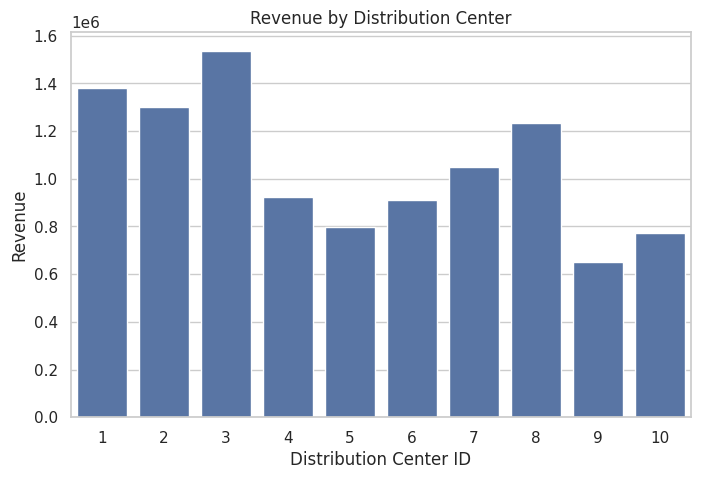

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=dc_perf.reset_index(),
            x='product_distribution_center_id', y='revenue')
plt.title('Revenue by Distribution Center')
plt.xlabel('Distribution Center ID')
plt.ylabel('Revenue')
plt.show()

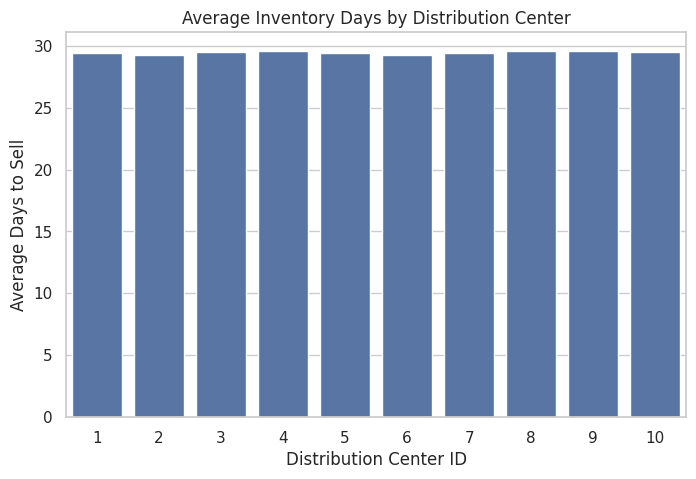

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=dc_perf.reset_index(),
            x='product_distribution_center_id', y='avg_inventory_days')
plt.title('Average Inventory Days by Distribution Center')
plt.xlabel('Distribution Center ID')
plt.ylabel('Average Days to Sell')
plt.show()

### 5.8 Top Products Analysis

In [ ]:
product_perf = sold_df.groupby(['product_name', 'product_category', 'product_brand']).agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum'),
    avg_inventory_days=('inventory_days', 'mean')
).sort_values(by='revenue', ascending=False)

product_perf.head(10)

,,,items_sold,revenue,profit,avg_inventory_days
product_name,product_category,product_brand,,,,
The North Face Apex Bionic Mens Soft Shell Ski Jacket 2013,Outerwear & Coats,The North Face,14,12642.00000,6763.469978,35.642857
Nobis Merideth Parka,Outerwear & Coats,Nobis,14,11130.00000,5776.470014,32.428571
Canada Goose Women's Solaris,Active,Canada Goose,14,9730.00000,6071.519980,31.500000
True Religion Men's Ricky Straight Jean,Jeans,True Religion,37,9471.55011,4375.323202,32.081081
The North Face Apex Bionic Soft Shell Jacket - Men's,Active,The North Face,10,9030.00000,5110.979980,33.100000
The North Face Nuptse 2 Jacket Deep Water Blue Mens,Outerwear & Coats,The North Face,10,9030.00000,5354.789986,40.100000
Diesel Men's Shioner Skinny Straight Leg Jean,Jeans,Diesel,30,8847.34996,4129.901047,23.333333
Canada Goose Men's The Chateau Jacket,Outerwear & Coats,Canada Goose,10,8150.00000,4368.399987,34.300000
AIR JORDAN DOMINATE SHORTS MENS 465071-100,Shorts,Jordan,9,8127.00000,4039.119000,41.777778


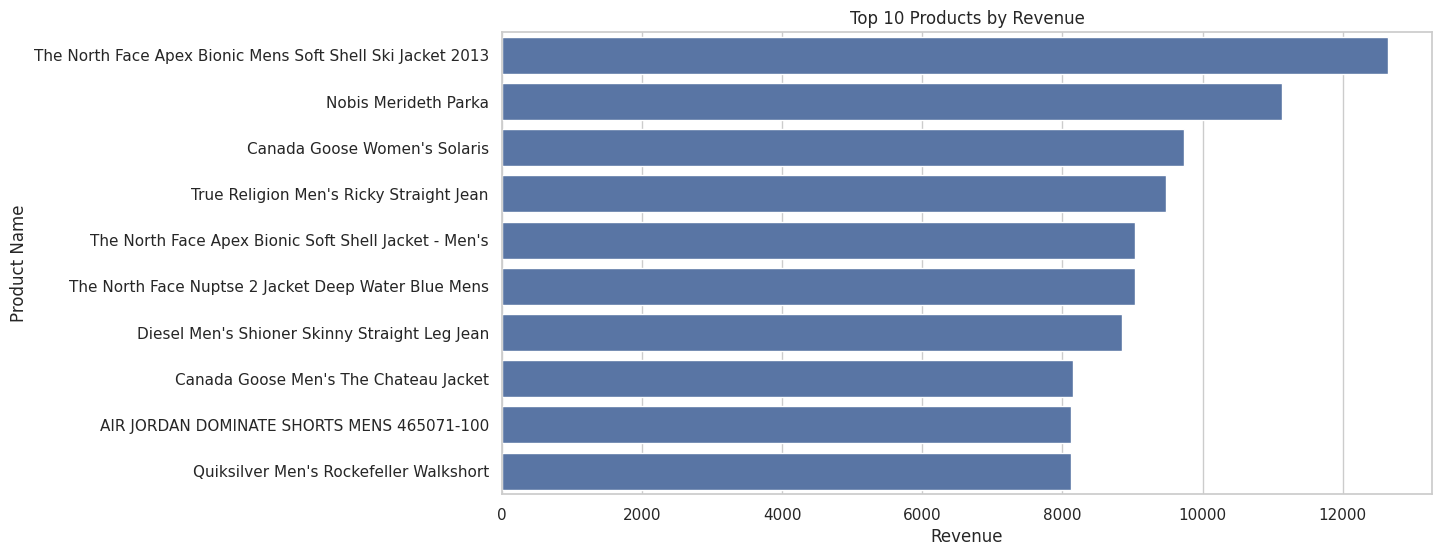

In [ ]:
top_products = product_perf.head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_products, x='revenue', y='product_name')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Name')
plt.show()

### 5.9 Slow-Moving Inventory Analysis

In [ ]:
slow_moving = sold_df.sort_values(by='inventory_days', ascending=False)[[
    'product_name', 'product_category', 'product_brand',
    'product_retail_price', 'profit', 'inventory_days'
]].head(20)

slow_moving

,product_name,product_category,product_brand,product_retail_price,profit,inventory_days
73139,Super Slimming Sleeveless V Neck Sequin Fitted...,Dresses,Hot from Hollywood,36.990002,18.531991,59.0
350956,Betsey Johnson Women's 2 Pack Jammin' Jungle C...,Socks & Hosiery,Betsey Johnson,20.000000,12.760000,59.0
371217,Men's Single Breasted One Button Black 3 Pcs V...,Suits & Sport Coats,Abini,89.949997,51.991098,59.0
220632,Perry Ellis Portfolio Men's Lamb Open Bottom J...,Outerwear & Coats,Perry Ellis,230.139999,124.505740,59.0
220568,Perry Ellis Men's Microfiber Blouson,Outerwear & Coats,Perry Ellis,59.990002,32.514581,59.0
220325,Outdoor Research Women's Igneo Jacket,Outerwear & Coats,Outdoor Research,279.950012,153.972507,59.0
220188,Original Penguin Men's Peacoat,Outerwear & Coats,Original Penguin,157.500000,92.767500,59.0
440878,AnimalShirtsUSA-Gir... Half Skin Womens Top - ...,Tops & Tees,AnimalShirtsUSA,24.950001,12.075800,59.0
40725,Merrell Women's Ellenwood Insulated Coat,Active,Merrell,239.910004,132.910141,59.0
169598,RVCA Men's Heavy Chev Denim Pant,Jeans,RVCA,71.949997,31.154349,59.0


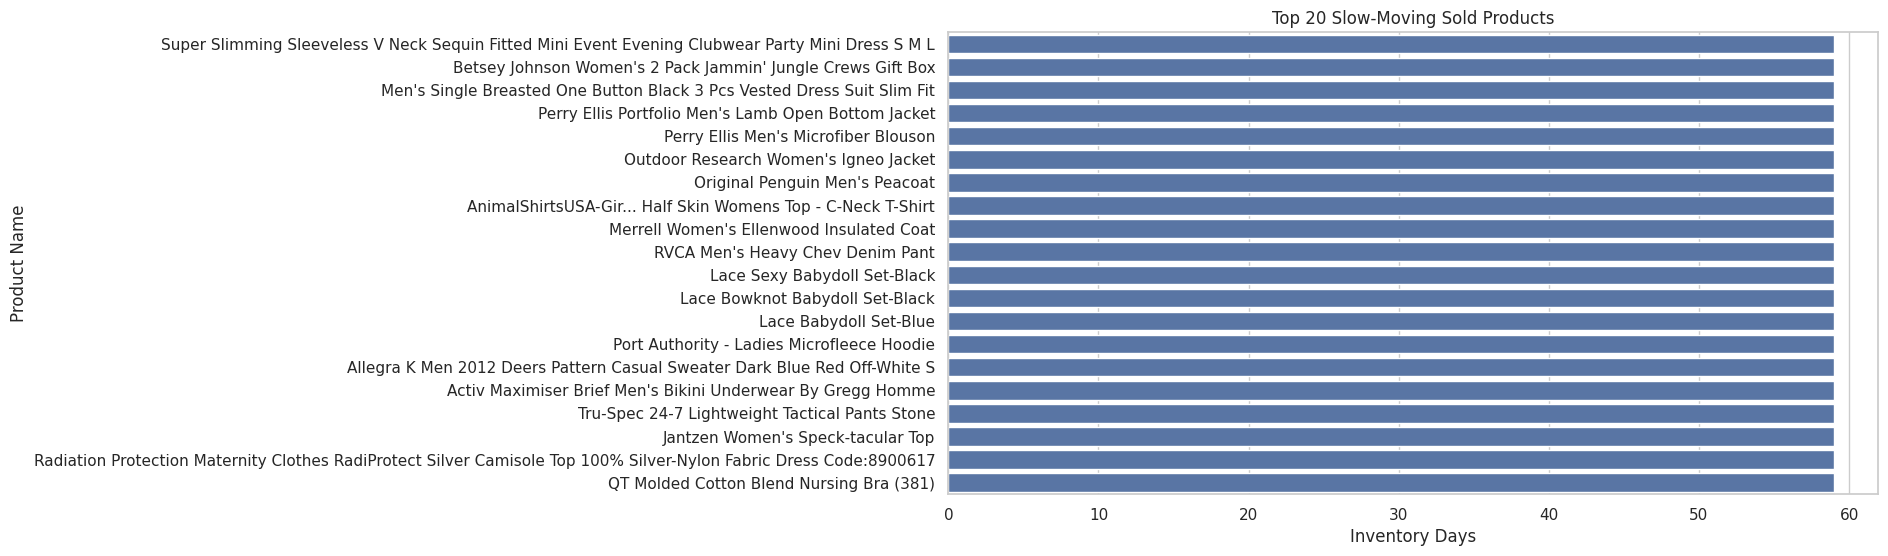

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=slow_moving,
            x='inventory_days', y='product_name')
plt.title('Top 20 Slow-Moving Sold Products')
plt.xlabel('Inventory Days')
plt.ylabel('Product Name')
plt.show()

### 5.10 Monthly Sales Trend

In [ ]:
monthly_sales = sold_df.groupby('sold_month').agg(
    items_sold=('id', 'count'),
    revenue=('product_retail_price', 'sum'),
    profit=('profit', 'sum')
).reset_index()

monthly_sales.head()

,sold_month,items_sold,revenue,profit
0,2019-01,32,1965.080007,986.173184
1,2019-02,53,4015.890006,2103.029722
2,2019-03,123,8088.340017,4205.258070
3,2019-04,151,9068.450037,4637.796408
4,2019-05,249,16128.430004,8458.945345


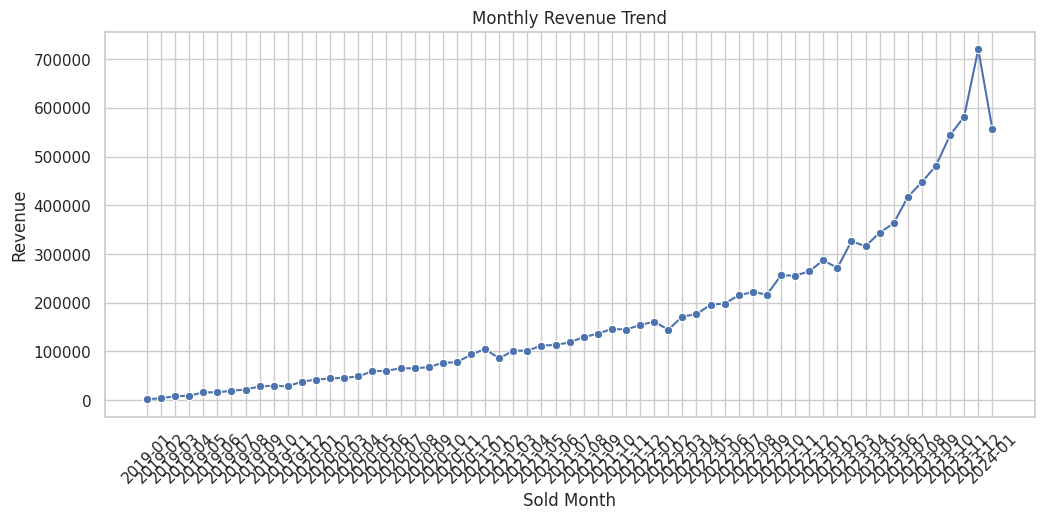

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='sold_month', y='revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Sold Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

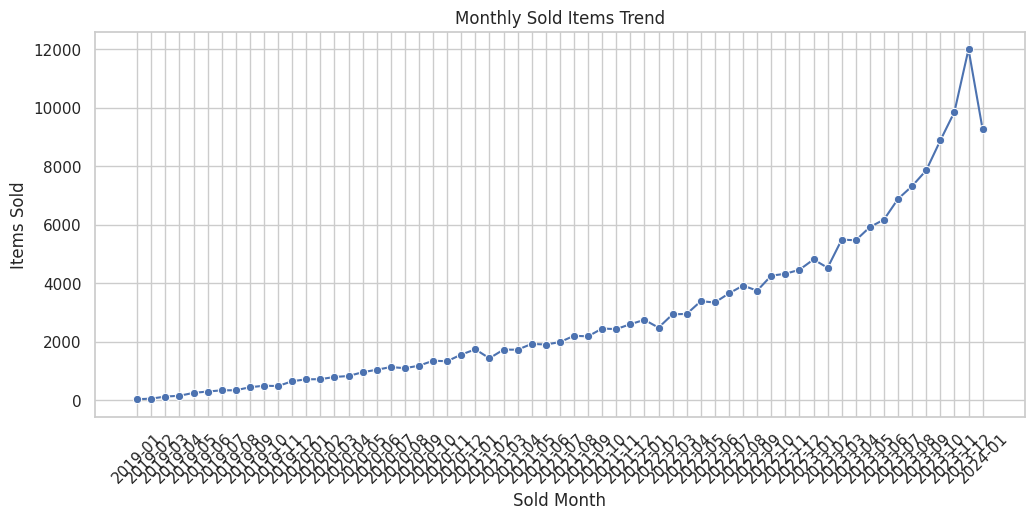

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='sold_month', y='items_sold', marker='o')
plt.title('Monthly Sold Items Trend')
plt.xlabel('Sold Month')
plt.ylabel('Items Sold')
plt.xticks(rotation=45)
plt.show()

### 5.11 Correlation Analysis

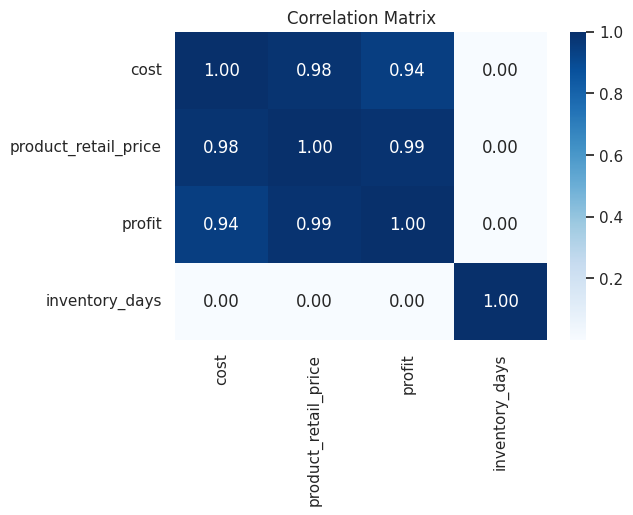

In [ ]:
analysis_df = sold_df[['cost', 'product_retail_price', 'profit', 'inventory_days']].copy()
corr = analysis_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## SECTION 6 — Additional DA Enhancements

### 6.1 Inventory Aging Bucket

In [ ]:
bins = [-1, 30, 90, 180, np.inf]
labels = ['0-30 days', '31-90 days', '91-180 days', '>180 days']

sold_df['inventory_age_bucket'] = pd.cut(
    sold_df['inventory_days'],
    bins=bins,
    labels=labels
)

sold_df['inventory_age_bucket'].value_counts()

,count
inventory_age_bucket,
0-30 days,91805
31-90 days,85395
91-180 days,0
>180 days,0


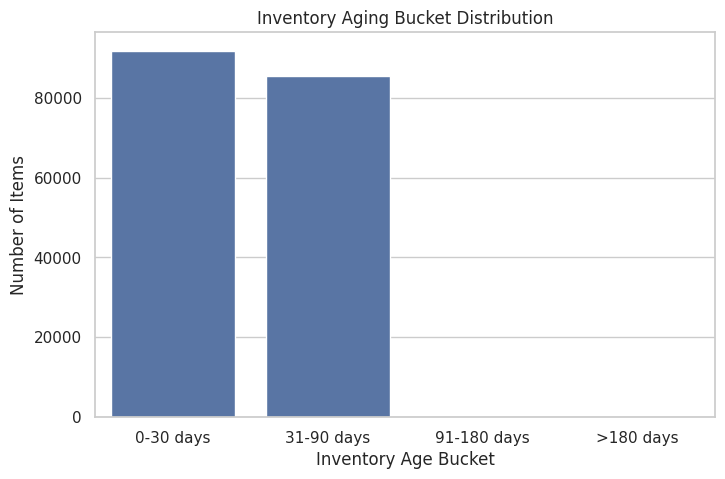

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=sold_df, x='inventory_age_bucket', order=labels)
plt.title('Inventory Aging Bucket Distribution')
plt.xlabel('Inventory Age Bucket')
plt.ylabel('Number of Items')
plt.show()

### 6.2 ABC Classification Based on Revenue

In [ ]:
product_abc = sold_df.groupby('product_name').agg(
    revenue=('product_retail_price', 'sum')
).sort_values(by='revenue', ascending=False).reset_index()

product_abc['cum_revenue_pct'] = product_abc['revenue'].cumsum() / product_abc['revenue'].sum()

def classify_abc(x):
    if x <= 0.80:
        return 'A'
    elif x <= 0.95:
        return 'B'
    else:
        return 'C'

product_abc['abc_class'] = product_abc['cum_revenue_pct'].apply(classify_abc)

product_abc.head(10)

,product_name,revenue,cum_revenue_pct,abc_class
0,The North Face Apex Bionic Soft Shell Jacket -...,22575.00000,0.002139,A
1,NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...,16254.00000,0.003679,A
2,Canada Goose Women's Solaris,13900.00000,0.004996,A
3,Canada Goose Men's The Chateau Jacket,13040.00000,0.006232,A
4,The North Face Apex Bionic Mens Soft Shell Ski...,12642.00000,0.007430,A
5,Canada Goose Women's Mystique,12000.00000,0.008567,A
6,Nobis Merideth Parka,11130.00000,0.009621,A
7,The North Face Denali Down Womens Jacket 2013,10836.00000,0.010648,A
8,True Religion Men's Ricky Straight Jean,9471.55011,0.011545,A
9,The North Face Nuptse 2 Jacket Deep Water Blue...,9030.00000,0.012401,A


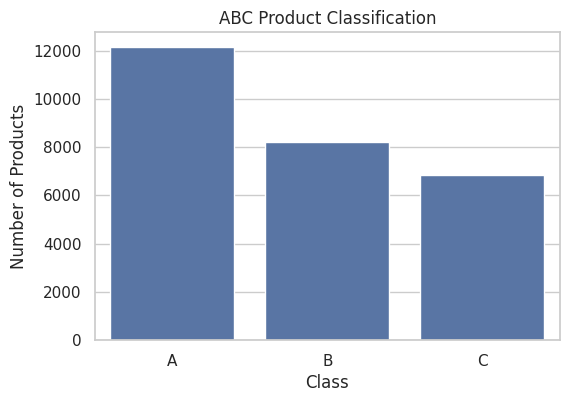

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=product_abc, x='abc_class', order=['A', 'B', 'C'])
plt.title('ABC Product Classification')
plt.xlabel('Class')
plt.ylabel('Number of Products')
plt.show()

## SECTION 7 — Key Business Insights

### Key Insights

1. Certain categories contribute the highest revenue, indicating where the company should focus inventory investment.
2. Some categories and products take significantly longer to sell, suggesting slow-moving inventory and inefficient capital allocation.
3. Brand-level performance differs substantially, showing that not all brands contribute equally to profitability.
4. Distribution centers may have different turnover speeds, which can signal operational inefficiencies or regional demand variation.
5. Monthly sales trends reveal fluctuations in demand that can support stock planning and seasonal forecasting.

## SECTION 8 — Business Recommendations

### Recommendations

1. Increase stock allocation for high-revenue and high-profit categories.
2. Review slow-moving products and consider discounting, bundling, or reducing reorder volume.
3. Prioritize brands with consistently high revenue and healthy profit margins.
4. Investigate distribution centers with slower average inventory turnover.
5. Use monthly trend patterns to improve procurement and inventory planning.

## SECTION 9 — Export Cleaned Data and Summary Tables

In [ ]:
# Export cleaned dataset
df.to_csv('inventory_items_cleaned.csv', index=False)

# Export summary tables
category_perf.to_csv('category_performance_summary.csv')
brand_perf.to_csv('brand_performance_summary.csv')
department_perf.to_csv('department_performance_summary.csv')
dc_perf.to_csv('distribution_center_performance_summary.csv')
monthly_sales.to_csv('monthly_sales_summary.csv', index=False)
product_abc.to_csv('abc_classification_summary.csv', index=False)

print("All files exported successfully!")

All files exported successfully!


In [ ]:
# Convert the inventory_items_cleaned to parquet
df.to_parquet('inventory_items_cleaned.parquet')

## Dashboard Suggestion

You can build a dashboard with 4 main sections:

1. **Executive Overview**
   - Total items
   - Sold rate
   - Realized revenue
   - Realized profit
   - Average inventory days

2. **Category & Brand Performance**
   - Revenue by category
   - Profit by category
   - Top brands

3. **Inventory Efficiency**
   - Average inventory days by category
   - Slow-moving products
   - Sold vs unsold distribution

4. **Time Trends & Distribution Center**
   - Monthly revenue trend
   - Monthly sold items trend
   - Distribution center performance